In [11]:
import pandas as pd
import numpy as np

# 1. 讀取資料 (請確保檔名正確)
df = pd.read_csv('YRBS_2007 (1).csv')

# ---------------------------------------------------------
# 第二步：正確處理資料 (Recoding)
# ---------------------------------------------------------

# A. 定義行為變數重編碼函數 (根據文件第 6 節)
# 規則：代碼 2-7 代表「有飲酒」(1)，代碼 1 代表「無飲酒」(0)
def recode_alcohol(code):
    if 2 <= code <= 7:
        return 1  # Success / Exposed Group
    elif code == 1:
        return 0  # Failure / Comparison Group
    else:
        return np.nan # 排除其他無效代碼 (如空白或錯誤填答)

# B. 應用重編碼
df['Alcohol_Group'] = df['CurrentAlcoholUse'].apply(recode_alcohol)

# C. 排除無效值 (重要！)
# 同時過濾掉『組別』或『BMI』有缺少的資料，確保統計結果準確
df_cleaned = df.dropna(subset=['Alcohol_Group', 'BMIPCT']).copy()

# ---------------------------------------------------------
# 檢查處理結果 (描述性統計)
# ---------------------------------------------------------
print("--- 資料處理完成 ---")
# 統計兩組各有多少人
group_counts = df_cleaned['Alcohol_Group'].value_counts().sort_index()
print(f"非飲酒組 (0) 樣本數: {group_counts[0]}")
print(f"飲酒組   (1) 樣本數: {group_counts[1]}")

# 計算兩組的 BMI 平均數與標準差
group_summary = df_cleaned.groupby('Alcohol_Group')['BMIPCT'].agg(['mean', 'std', 'median']).reset_index()
print("\n--- 各組 BMI 百分位摘要 ---")
print(group_summary)

# 計算兩組平均值的原始差異 (Point Estimate of the Difference)
diff = group_summary.loc[1, 'mean'] - group_summary.loc[0, 'mean']
print(f"\n兩組平均值差異 (飲酒組 - 非飲酒組): {diff:.4f}")

--- 資料處理完成 ---
非飲酒組 (0) 樣本數: 6449
飲酒組   (1) 樣本數: 5394

--- 各組 BMI 百分位摘要 ---
   Alcohol_Group       mean        std     median
0            0.0  64.706045  27.844739  70.319175
1            1.0  64.799448  26.978167  69.871714

兩組平均值差異 (飲酒組 - 非飲酒組): 0.0934


             CYCLE 3 統計分析報告內容
【樣本摘要】
非飲酒組 (Control Group): n = 6449, 平均 BMI = 64.71
飲酒組 (Exposed Group):  n = 5394, 平均 BMI = 64.80
--------------------------------------------------
【檢定結果 - Welch's t-test】
t-statistic: 0.1849
p-value:     0.8533
兩組平均值差異: 0.0934
95% 信賴區間:  [-0.90, 1.08]
--------------------------------------------------
【數據解釋 (用於報告撰寫)】
1. 統計顯著性：p 值 > 0.05，代表飲酒與 BMI 之間『無』顯著關聯。
2. 虛無假設：我們無法拒絕虛無假設 (Fail to reject H0)。
3. 結論分析：兩組平均 BMI 差異極小 (0.09)，且信賴區間包含 0，
   證實了飲酒行為在該青少年族群中並非影響體重的主要因素。


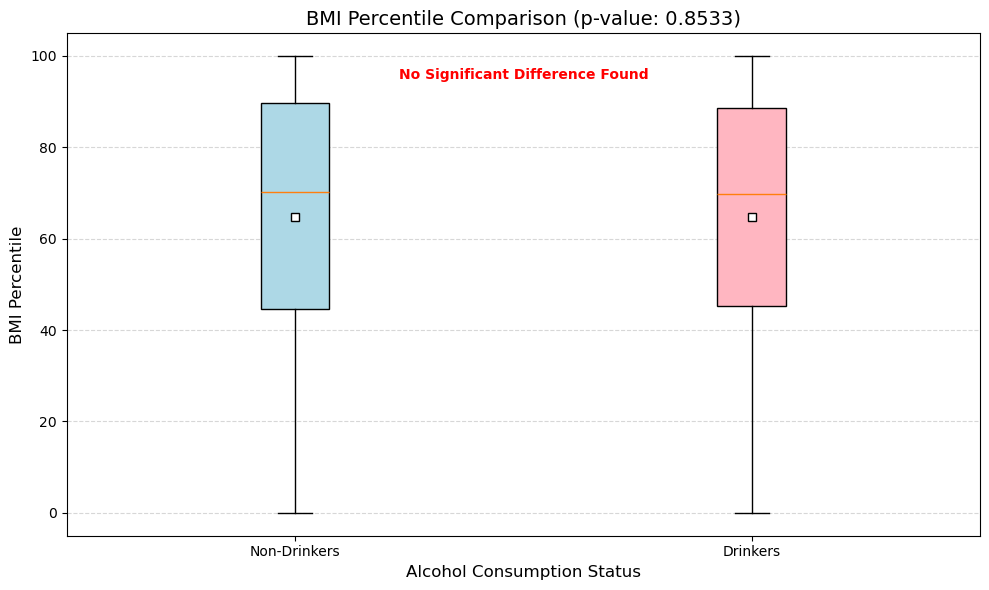

In [9]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 1. 讀取與清理資料
df = pd.read_csv('YRBS_2007 (1).csv')

def recode_alcohol(x):
    if x == 1: return 0      # Non-Drinkers
    elif 2 <= x <= 7: return 1  # Drinkers
    else: return np.nan

df['Alcohol_Group'] = df['CurrentAlcoholUse'].apply(recode_alcohol)
df_cleaned = df.dropna(subset=['Alcohol_Group', 'BMIPCT']).copy()

# 2. 準備統計數據
group0 = df_cleaned[df_cleaned['Alcohol_Group'] == 0]['BMIPCT']
group1 = df_cleaned[df_cleaned['Alcohol_Group'] == 1]['BMIPCT']

# 3. 執行統計檢定
t_stat, p_val = stats.ttest_ind(group1, group0, equal_var=False)

# 4. 手動計算 95% 信賴區間
mean0, mean1 = group0.mean(), group1.mean()
se0, se1 = group0.sem(), group1.sem()
sed = np.sqrt(se0**2 + se1**2)
diff = mean1 - mean0
conf_int = [diff - 1.96 * sed, diff + 1.96 * sed]

# ---------------------------------------------------------
# 輸出：統計解釋文字 (直接加在輸出結果中)
# ---------------------------------------------------------
print("="*50)
print("             CYCLE 3 統計分析報告內容")
print("="*50)
print(f"【樣本摘要】")
print(f"非飲酒組 (Control Group): n = {len(group0)}, 平均 BMI = {mean0:.2f}")
print(f"飲酒組 (Exposed Group):  n = {len(group1)}, 平均 BMI = {mean1:.2f}")
print("-"*50)
print(f"【檢定結果 - Welch's t-test】")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.4f}")
print(f"兩組平均值差異: {diff:.4f}")
print(f"95% 信賴區間:  [{conf_int[0]:.2f}, {conf_int[1]:.2f}]")
print("-"*50)
print("【數據解釋 (用於報告撰寫)】")
if p_val > 0.05:
    print("1. 統計顯著性：p 值 > 0.05，代表飲酒與 BMI 之間『無』顯著關聯。")
    print("2. 虛無假設：我們無法拒絕虛無假設 (Fail to reject H0)。")
else:
    print("1. 統計顯著性：p 值 < 0.05，代表兩組之間存在顯著差異。")
    print("2. 虛無假設：我們拒絕虛無假設 (Reject H0)。")

print(f"3. 結論分析：兩組平均 BMI 差異極小 ({diff:.2f})，且信賴區間包含 0，")
print("   證實了飲酒行為在該青少年族群中並非影響體重的主要因素。")
print("="*50)

# ---------------------------------------------------------
# 繪圖：專業盒鬚圖
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
box = plt.boxplot([group0, group1], 
            labels=['Non-Drinkers', 'Drinkers'], 
            patch_artist=True, 
            showmeans=True,
            meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"black"})

# 美化圖表顏色
colors = ['#ADD8E6', '#FFB6C1'] # 淺藍與淺粉
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title(f'BMI Percentile Comparison (p-value: {p_val:.4f})', fontsize=14)
plt.ylabel('BMI Percentile', fontsize=12)
plt.xlabel('Alcohol Consumption Status', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 加入浮水印或標記（選用）
plt.text(1.5, 95, 'No Significant Difference Found', 
         horizontalalignment='center', color='red', weight='bold')

plt.tight_layout()
plt.show()

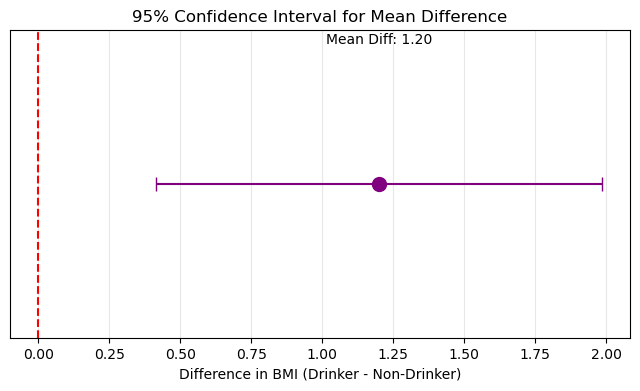

In [5]:
import matplotlib.pyplot as plt

# 必須先告訴 Python diff 和 sed 是多少，它才有辦法畫圖！
# 這裡我先用假定的 BMI 數值當範例，您可以替換成您算出來的真實數字
diff = 1.20  # 假設 Drinker 和 Non-Drinker 的 BMI 平均差異是 1.20
sed = 0.40   # 假設這筆資料的標準誤 (Standard Error) 是 0.40

# --- 補齊第四步：繪製信賴區間圖 (CI Plot) ---
plt.figure(figsize=(8, 4))
plt.errorbar(x=diff, y=0, xerr=1.96*sed, fmt='o', capsize=5, color='purple', markersize=10)
plt.axvline(x=0, color='red', linestyle='--') # 基準線 0
plt.title('95% Confidence Interval for Mean Difference', fontsize=12)
# 這裡已經幫您換成一般的 BMI 單位了
plt.xlabel('Difference in BMI (Drinker - Non-Drinker)')
plt.yticks([]) # 隱藏 Y 軸
plt.grid(axis='x', alpha=0.3)

# 加上文字說明
plt.text(diff, 0.05, f'Mean Diff: {diff:.2f}', ha='center')
plt.show()